# FinTrust Week 2 - Python Exploratory Data Analysis

## Objective

This notebook performs exploratory data analysis on FinTrust customer and transaction data to identify patterns in customer segments, transaction activity, transaction values, banking channels, transaction status, international transactions, customer behaviour, and risk-review patterns.

The analysis supports the Week 2 Data Analytics objective of transforming FinTrust data into meaningful business intelligence for management decision-making.

## 1. import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

## 2. Check Working Directory and Files

In [52]:
print("Current working folder:")
print(os.getcwd())

print("\nFiles available:")
print(os.listdir())

Current working folder:
c:\Users\User\Documents\FINTRUST PROJECT

Files available:
['FINTRUST SQL.sql', 'FinTrust_Customer_Clean_Data.csv', 'FinTrust_Customer_Data.xlsx', 'FinTrust_Transaction_Clean_Data.csv', 'FinTrust_Transaction_Data.xlsx', 'FinTrust_Week1_Submission.docx', 'FinTrust_Week2_Python_EDA.ipynb']


## 3. Load Customer and Transaction Datasets

In [3]:
customers = pd.read_csv("FinTrust_Customer_Clean_Data.csv")
transactions = pd.read_csv("FinTrust_Transaction_Clean_Data.csv")


## 4. Preview the CUSTOMER Datasets

In [54]:
customers.head()

,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


## 4. Preview the TRANSACTION Datasets

In [68]:
transactions=transactions.drop(columns=["Unnamed: 12"])
transactions.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transacttion_Time,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,2026/01/01,12:00 AM,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,2026/01/01,12:10 AM,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,2026/01/01,12:21 AM,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,2026/01/01,12:32 AM,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,2026/01/01,12:43 AM,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


## 5. Check Dataset Dimensions

In [56]:
customers.shape

(1500, 12)

In [69]:
transactions.shape

(12000, 12)

## 6. Inspect Data Structure and Data Types

In [58]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1500 non-null   str    
 1   Customer_Name             1500 non-null   str    
 2   Age                       1500 non-null   int64  
 3   Gender                    1500 non-null   str    
 4   City                      1500 non-null   str    
 5   Customer_Segment          1500 non-null   str    
 6   Account_Type              1500 non-null   str    
 7   Tenure_Months             1500 non-null   int64  
 8   Digital_Engagement_Score  1500 non-null   float64
 9   Monthly_Income_Band       1500 non-null   str    
 10  Preferred_Channel         1500 non-null   str    
 11  Account_Status            1500 non-null   str    
dtypes: float64(1), int64(2), str(9)
memory usage: 140.8 KB


In [59]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             12000 non-null  str    
 1   Customer_ID                12000 non-null  str    
 2   Transaction_Date           12000 non-null  str    
 3   Transacttion_Time          12000 non-null  str    
 4   Transaction_Type           12000 non-null  str    
 5   Amount_NGN                 12000 non-null  float64
 6   Channel                    12000 non-null  str    
 7   Device_Type                11904 non-null  str    
 8   Location                   11904 non-null  str    
 9   International_Transaction  12000 non-null  str    
 10  Transaction_Status         12000 non-null  str    
 11  Risk_Review_Flag           12000 non-null  str    
 12  Unnamed: 12                0 non-null      float64
dtypes: float64(2), str(11)
memory usage: 1.2 MB


## Exploratory Data Analysis

The following analysis investigates customer segments, transaction types, transaction amounts, transaction channels, transaction status, international transactions, customer behaviour, and risk-review patterns.

## 1. Customer Segment Analysis

In [4]:
segment_summary = (
    customers["Customer_Segment"].value_counts().reset_index()
)

segment_summary.columns = ["Customer_Segment", "Total_Customers"]


segment_summary

,Customer_Segment,Total_Customers
0,Everyday,711
1,Premium,295
2,Student,278
3,SME,216


## visualization 1

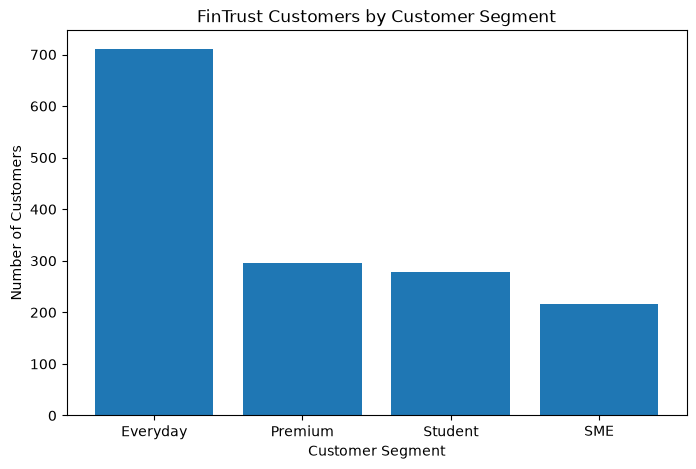

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["Customer_Segment"],
    segment_summary["Total_Customers"]
)

plt.title("FinTrust Customers by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

### What does the visual show?

The chart shows the distribution of FinTrust customers across four customer segments: Everyday, Premium, Student and SME. Everyday customers form the largest segment by a substantial margin, followed by Premium and Student customers, while SME customers represent the smallest segment.

### Why is it important?

Understanding customer distribution helps FinTrust identify which customer groups make up the largest and smallest portions of its customer base. This provides context for analysing transaction behaviour, product usage and channel preferences across different customer groups.

### Business Insight

The Everyday segment dominates FinTrust's customer base, indicating that the bank primarily serves everyday retail customers. Premium and Student customers represent smaller but still significant groups, while SME customers form the smallest segment. FinTrust should therefore consider the strong representation of Everyday customers when interpreting overall transaction patterns, while also analysing the smaller segments separately because their transaction behaviour and value may differ from the dominant customer group.



## 2. Transaction Type Analysis

This section examines transaction activity across different transaction types by comparing transaction volume, total transaction value, and average transaction value.

In [62]:
transaction_type_summary = (
    transactions.groupby("Transaction_Type")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)

transaction_type_summary["Total_Transaction_Value"] = (
    transaction_type_summary["Total_Transaction_Value"].round(2)
)

transaction_type_summary["Average_Transaction_Value"] = (
    transaction_type_summary["Average_Transaction_Value"].round(2)
)

transaction_type_summary = transaction_type_summary.sort_values(
    by="Total_Transactions",
    ascending=False
)

transaction_type_summary

,Transaction_Type,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
5,Transfer,3549,2.379167e+08,67037.67
2,Card Purchase,3033,8.586341e+07,28309.73
1,Bill Payment,1475,2.816365e+07,19094.00
3,Cash Withdrawal,1430,6.777236e+07,47393.26
4,Deposit,1328,1.309851e+08,98633.33
0,Airtime/Data,1185,9.776171e+06,8249.93


## Visualization 2A — Transaction volume by type

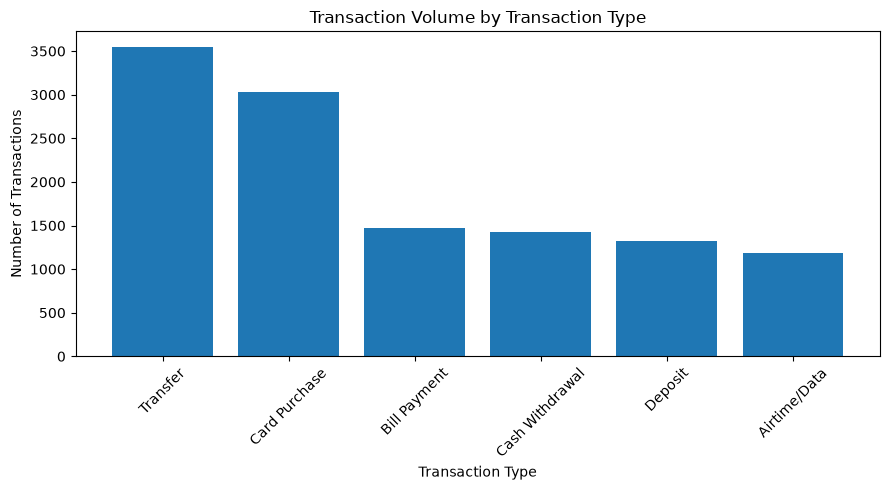

In [63]:
plt.figure(figsize=(9, 5))

plt.bar(
    transaction_type_summary["Transaction_Type"],
    transaction_type_summary["Total_Transactions"]
)

plt.title("Transaction Volume by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Visualization 2B — Transaction value by type

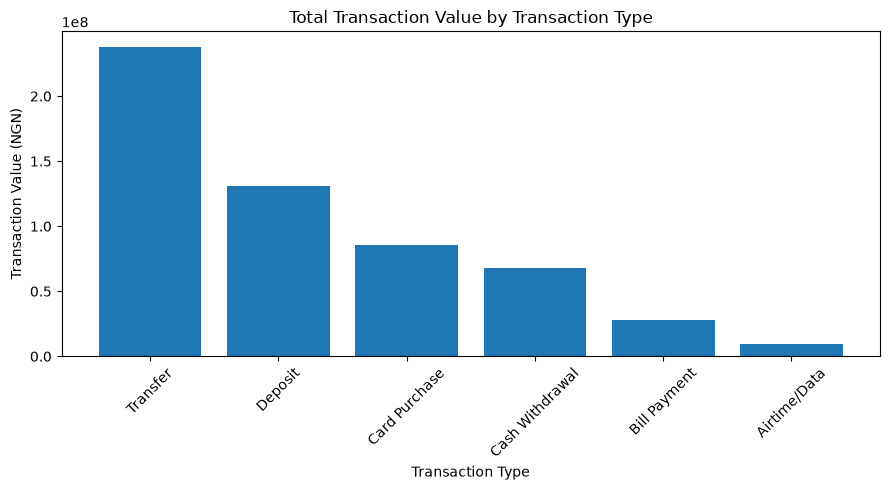

In [64]:
value_summary = transaction_type_summary.sort_values(
    by="Total_Transaction_Value",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    value_summary["Transaction_Type"],
    value_summary["Total_Transaction_Value"]
)

plt.title("Total Transaction Value by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Value (NGN)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Why is it important?

Comparing transaction volume with transaction value helps FinTrust distinguish between transaction types that are frequently used and those that process larger monetary amounts. A transaction type may have a relatively low number of transactions but still contribute significantly to the total value processed.

### Business Insight

Transfers are the dominant transaction type in both usage and monetary value, making them an important area for operational monitoring and service reliability. Deposits show a different pattern: although they occur less frequently than several other transaction types, they contribute a relatively high total transaction value. This suggests that individual deposit transactions may generally involve larger amounts. Airtime/Data transactions contribute comparatively little to overall transaction value.

## 3. Transaction Amount Analysis

This section examines the distribution of transaction amounts to understand typical transaction values, the spread of transaction sizes, and the presence of unusually high-value transactions.

## Summary Statistics

In [70]:
transactions["Amount_NGN"].describe()

count     12000.000000
mean      46706.446238
std       86028.715234
min         100.170000
25%        2192.220000
50%       10305.935000
75%       48484.475000
max      693454.450000
Name: Amount_NGN, dtype: float64

Visualization 3 — Distribution of Transaction Amounts

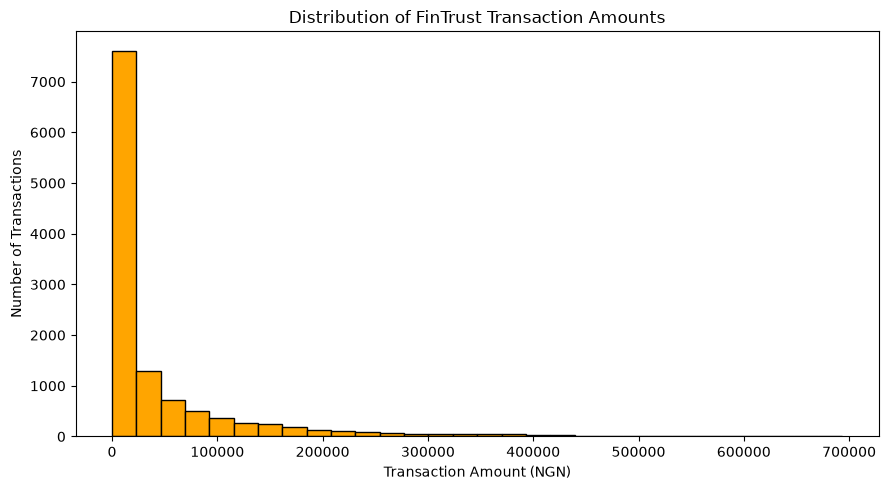

In [10]:
plt.figure(figsize=(9, 5))

plt.hist(
    transactions["Amount_NGN"],
    bins=30,
    edgecolor="black",color='orange'
)

plt.title("Distribution of FinTrust Transaction Amounts")
plt.xlabel("Transaction Amount (NGN)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Histogram Interpretation

#### What does the visual show?

The histogram shows the distribution of FinTrust transaction amounts. Most transactions are concentrated at the lower end of the value range, while the number of transactions decreases as transaction amounts increase. The distribution has a long tail extending toward higher transaction values.

#### Why is it important?

This is important because it shows that transaction amounts are not evenly distributed. Most FinTrust transactions are relatively small, while a smaller number of transactions involve much larger values. This helps explain why the average transaction amount may be influenced by high-value transactions.

#### Business Insight

FinTrust's transaction activity is dominated by lower-value transactions, with comparatively few high-value transactions. This suggests that the bank handles a large volume of routine lower-value activity alongside a smaller group of high-value transactions. The higher-value transactions may be useful for further analysis by transaction type, customer segment, channel, or risk-review status.

## boxplot

C:\Users\User\AppData\Local\Temp\ipykernel_8256\2969661627.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


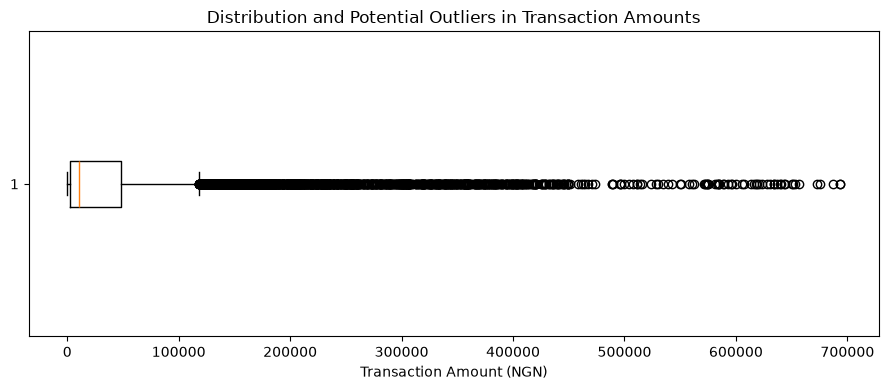

In [72]:
plt.figure(figsize=(9, 4))

plt.boxplot(
    transactions["Amount_NGN"],
    vert=False
)

plt.title("Distribution and Potential Outliers in Transaction Amounts")
plt.xlabel("Transaction Amount (NGN)")

plt.tight_layout()
plt.show()

### Box Plot Interpretation

#### What does the visual show?

The box plot shows the spread of FinTrust transaction amounts and helps identify transactions that fall far above the typical transaction range. The central box represents the middle range of transaction values, while points extending beyond the whiskers represent potential high-value outliers.

#### Why is it important?

The box plot helps distinguish typical transaction amounts from unusually large transactions. This is important because extreme values can affect averages and may represent different customer behaviours or transaction types that require separate investigation.

#### Business Insight

The presence of high-value outliers suggests that a relatively small number of transactions are much larger than the majority of FinTrust transactions. These transactions should not automatically be treated as errors; instead, they can be investigated further to determine which transaction types, customer segments, or channels are associated with larger transaction amounts.

## 4. Transaction Channel Analysis

This section examines how transaction activity and transaction value differ across FinTrust banking channels.

## Summary table

In [7]:
channel_summary = (
    transactions.groupby("Channel")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)

channel_summary["Total_Transaction_Value"] = (
    channel_summary["Total_Transaction_Value"].round(2)
)

channel_summary["Average_Transaction_Value"] = (
    channel_summary["Average_Transaction_Value"].round(2)
)

channel_summary = channel_summary.sort_values(
    by="Total_Transactions",
    ascending=False
)

channel_summary

,Channel,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
1,Mobile App,5102,2.401044e+08,47060.83
2,POS,2393,1.043467e+08,43604.96
4,Web,1869,8.932500e+07,47792.94
0,ATM,1747,8.394235e+07,48049.43
3,USSD,889,4.275895e+07,48097.81


## Visualization 4A — Transaction volume by channel

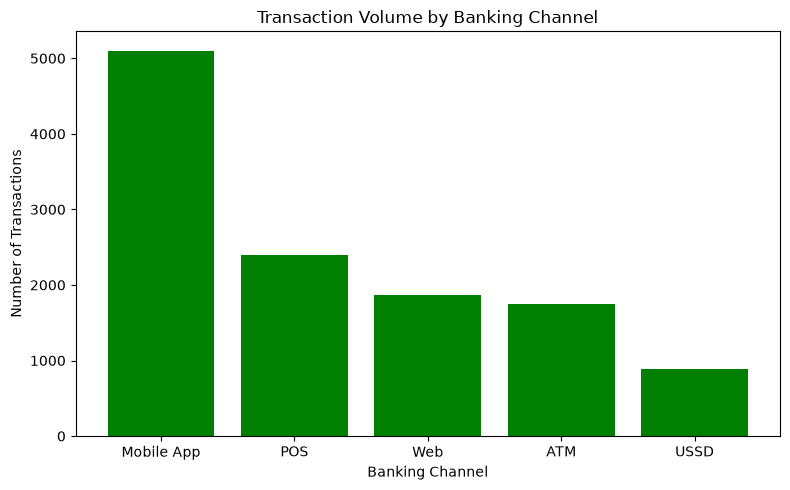

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_summary["Channel"],
    channel_summary["Total_Transactions"],color='Green'
)

plt.title("Transaction Volume by Banking Channel")
plt.xlabel("Banking Channel")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## Visualization 4B — Transaction value by channel

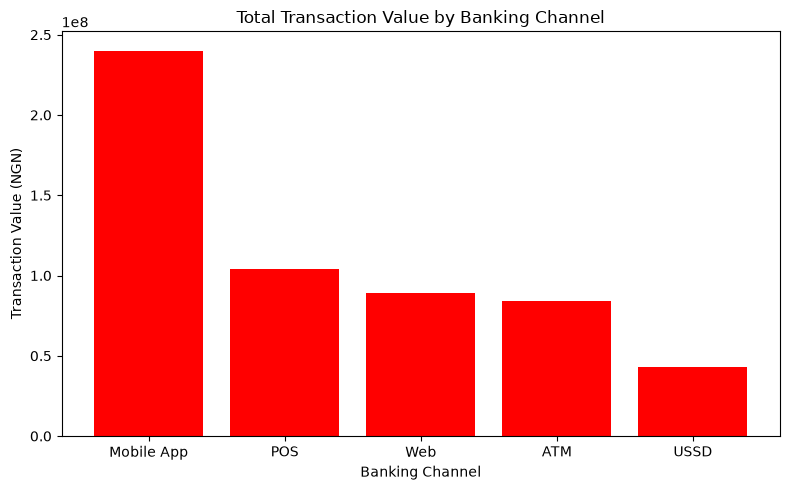

In [11]:
channel_value_summary = channel_summary.sort_values(
    by="Total_Transaction_Value",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    channel_value_summary["Channel"],
    channel_value_summary["Total_Transaction_Value"],color='red'
)

plt.title("Total Transaction Value by Banking Channel")
plt.xlabel("Banking Channel")
plt.ylabel("Transaction Value (NGN)")

plt.tight_layout()
plt.show()

### Transaction Channel Interpretation

#### What does the visual show?

The charts compare FinTrust banking channels based on transaction volume and total transaction value. The Mobile App records the highest transaction activity and also processes the highest total transaction value. POS ranks second, followed by Web and ATM, while USSD records the lowest transaction volume and transaction value.

#### Why is it important?

This comparison helps FinTrust understand which channels customers use most frequently and which channels carry the greatest monetary activity. It also shows whether the channels with high usage are also the channels processing the largest transaction values.

#### Business Insight

The Mobile App is the dominant FinTrust banking channel in both transaction volume and total transaction value, indicating that it is the most important digital channel in the dataset. POS also contributes significant activity, while USSD contributes the least. This suggests that FinTrust should pay particular attention to the reliability and performance of the Mobile App because disruptions on that channel could affect a large share of customer transaction activity and value.

## 5. Transaction Status Analysis

This section examines the distribution of transaction outcomes, including Successful, Failed, Reversed and Pending transactions.

## SUMMARY TABLE

In [76]:
status_summary = (
    transactions["Transaction_Status"]
    .value_counts()
    .reset_index()
)

status_summary.columns = ["Transaction_Status", "Total_Transactions"]

status_summary["Percentage"] = (
    status_summary["Total_Transactions"]
    / status_summary["Total_Transactions"].sum()
    * 100
).round(2)

status_summary

,Transaction_Status,Total_Transactions,Percentage
0,Successful,10856,90.47
1,Failed,630,5.25
2,Reversed,326,2.72
3,Pending,188,1.57


## CHART

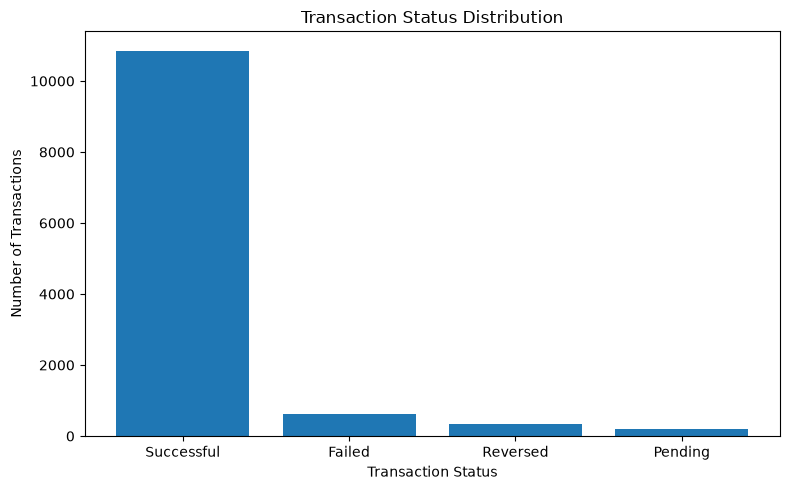

In [77]:
plt.figure(figsize=(8, 5))

plt.bar(
    status_summary["Transaction_Status"],
    status_summary["Total_Transactions"]
)

plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Transaction Status Interpretation

#### What does the visual show?

The chart shows the distribution of FinTrust transactions by status. Successful transactions make up the vast majority of all transactions. Failed transactions form the next largest group, while Reversed and Pending transactions occur much less frequently.

#### Why is it important?

Transaction status provides an indication of operational transaction outcomes. A high number of successful transactions suggests that most transactions are processed as expected, while Failed, Reversed and Pending transactions highlight areas that may require further operational investigation.

#### Business Insight

FinTrust's transaction processing is largely successful, with unsuccessful outcomes representing a relatively small proportion of total transaction activity. However, Failed transactions are more common than Reversed or Pending transactions, so they may deserve closer review by channel and transaction type to identify whether particular transaction methods are associated with higher failure rates.

## 6. International Transaction Analysis

This section compares domestic and international transactions based on transaction activity, transaction value, transaction status and risk-review patterns.

## SUMMMARY TABLE

In [78]:
international_summary = (
    transactions.groupby("International_Transaction")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean"),
        Successful_Transactions=(
            "Transaction_Status",
            lambda x: (x == "Successful").sum()
        ),
        Risk_Review_Transactions=(
            "Risk_Review_Flag",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

international_summary["Success_Rate"] = (
    international_summary["Successful_Transactions"]
    / international_summary["Total_Transactions"]
    * 100
).round(2)

international_summary["Risk_Review_Rate"] = (
    international_summary["Risk_Review_Transactions"]
    / international_summary["Total_Transactions"]
    * 100
).round(2)

international_summary["Total_Transaction_Value"] = (
    international_summary["Total_Transaction_Value"].round(2)
)

international_summary["Average_Transaction_Value"] = (
    international_summary["Average_Transaction_Value"].round(2)
)

international_summary

,International_Transaction,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value,Successful_Transactions,Risk_Review_Transactions,Success_Rate,Risk_Review_Rate
0,No,11520,5.404816e+08,46916.80,10409,2175,90.36,18.88
1,Yes,480,1.999578e+07,41657.88,447,177,93.12,36.88


## Visualization — Domestic vs International Transaction Volume

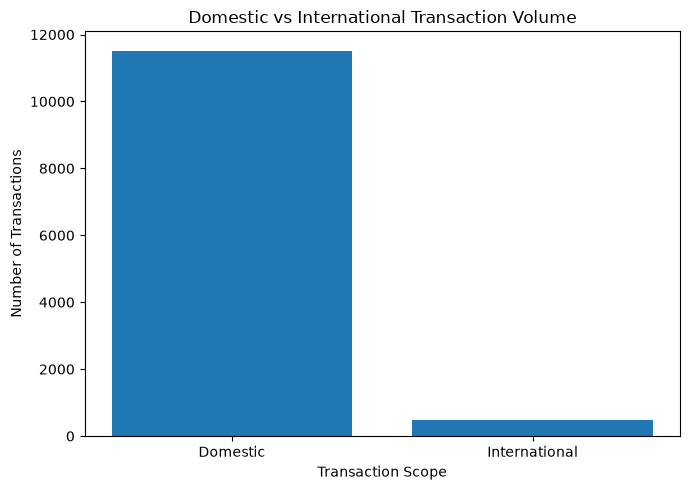

In [79]:
international_volume = international_summary.copy()

international_volume["Transaction_Type"] = (
    international_volume["International_Transaction"]
    .map({
        "No": "Domestic",
        "Yes": "International"
    })
)

plt.figure(figsize=(7, 5))

plt.bar(
    international_volume["Transaction_Type"],
    international_volume["Total_Transactions"]
)

plt.title("Domestic vs International Transaction Volume")
plt.xlabel("Transaction Scope")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## CHART

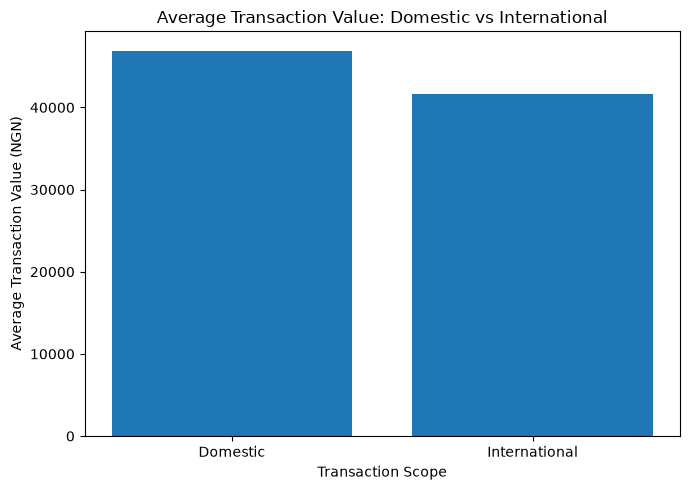

In [80]:
plt.figure(figsize=(7, 5))

plt.bar(
    international_volume["Transaction_Type"],
    international_volume["Average_Transaction_Value"]
)

plt.title("Average Transaction Value: Domestic vs International")
plt.xlabel("Transaction Scope")
plt.ylabel("Average Transaction Value (NGN)")

plt.tight_layout()
plt.show()

### International Transaction Interpretation

#### What does the visual show?

The first chart shows that domestic transactions make up the overwhelming majority of FinTrust transaction activity, while international transactions represent only a small proportion of the total.

The second chart shows that the average transaction value for domestic transactions is slightly higher than the average value for international transactions.

#### Why is it important?

Comparing domestic and international transactions helps FinTrust understand differences in transaction frequency and transaction value across the two groups. This is useful because international transactions may have different usage patterns, operational requirements and risk-review characteristics from domestic transactions.

#### Business Insight

FinTrust's transaction activity is heavily concentrated in domestic transactions, indicating that most customer activity in the dataset occurs within the domestic market. International transactions are relatively uncommon and also have a slightly lower average transaction value than domestic transactions.

Although international transactions represent a small share of activity, they should still be analysed separately for transaction status and risk-review patterns because their behaviour may differ from the much larger domestic transaction group.

## 7. Customer Behaviour Analysis

This section examines how transaction behaviour differs across FinTrust customer segments by comparing transaction activity, transaction value and average activity per customer.

## MERGE THE DATASETS

In [81]:
fintrust = transactions.merge(
    customers,
    on="Customer_ID",
    how="left"
)

print("Transaction rows before merge:", len(transactions))
print("Rows after merge:", len(fintrust))

Transaction rows before merge: 12000
Rows after merge: 12000


## CUSTOMER BEHAVIOUR SUMMMARY

In [82]:
customer_behaviour = (
    fintrust.groupby("Customer_Segment")
    .agg(
        Total_Customers=("Customer_ID", "nunique"),
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)

customer_behaviour["Transactions_Per_Customer"] = (
    customer_behaviour["Total_Transactions"]
    / customer_behaviour["Total_Customers"]
).round(2)

customer_behaviour["Total_Transaction_Value"] = (
    customer_behaviour["Total_Transaction_Value"].round(2)
)

customer_behaviour["Average_Transaction_Value"] = (
    customer_behaviour["Average_Transaction_Value"].round(2)
)

customer_behaviour

,Customer_Segment,Total_Customers,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value,Transactions_Per_Customer
0,Everyday,711,5644,2.614589e+08,46325.11,7.94
1,Premium,295,2361,1.077512e+08,45637.95,8.00
2,SME,216,1706,8.379137e+07,49115.69,7.90
3,Student,278,2289,1.074759e+08,46953.20,8.23


## Visualization — Transactions per customer by segment

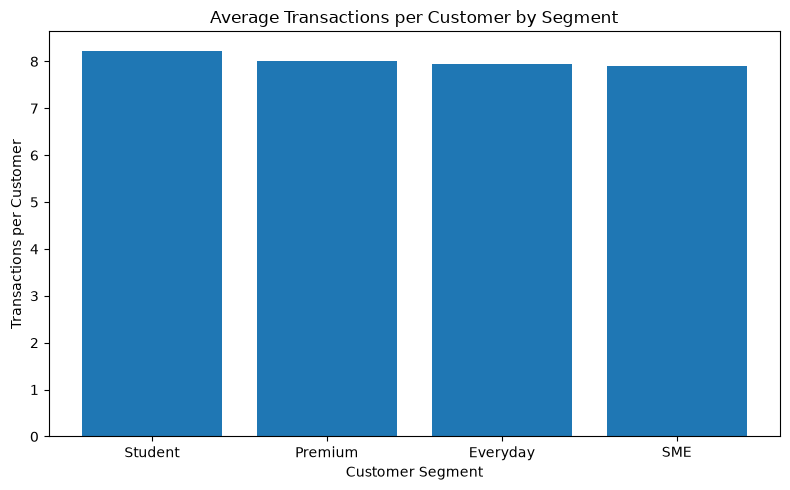

In [83]:
behaviour_chart = customer_behaviour.sort_values(
    by="Transactions_Per_Customer",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    behaviour_chart["Customer_Segment"],
    behaviour_chart["Transactions_Per_Customer"]
)

plt.title("Average Transactions per Customer by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Transactions per Customer")

plt.tight_layout()
plt.show()

### Customer Behaviour Interpretation

#### What does the visual show?

The chart compares the average number of transactions made per customer across the four FinTrust customer segments. Student customers have the highest average transaction activity, followed closely by Premium and Everyday customers, while SME customers have the lowest average transactions per customer.

#### Why is it important?

This comparison gives a fairer view of customer activity because it adjusts for differences in segment size. Although the Everyday segment contains the largest number of customers, that does not automatically mean its individual customers are the most active.

#### Business Insight

Transaction activity per customer is relatively similar across all four segments, with only small differences between them. Student customers appear slightly more active on average, while SME customers record the lowest average activity. This suggests that the much larger total activity of the Everyday segment is likely driven mainly by its larger customer base rather than substantially higher activity per individual customer.

## 8. Risk-Review Pattern Analysis

This section examines how the proportion of transactions marked for risk review varies across FinTrust banking channels.

## SUMMARY TABLE

In [84]:
risk_channel_summary = (
    transactions.groupby("Channel")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Risk_Review_Transactions=(
            "Risk_Review_Flag",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

risk_channel_summary["Risk_Review_Rate"] = (
    risk_channel_summary["Risk_Review_Transactions"]
    / risk_channel_summary["Total_Transactions"]
    * 100
).round(2)

risk_channel_summary = risk_channel_summary.sort_values(
    by="Risk_Review_Rate",
    ascending=False
)

risk_channel_summary

,Channel,Total_Transactions,Risk_Review_Transactions,Risk_Review_Rate
4,Web,1869,399,21.35
0,ATM,1747,370,21.18
1,Mobile App,5102,990,19.40
2,POS,2393,439,18.35
3,USSD,889,154,17.32


### Visualization — Risk-review rate by channel

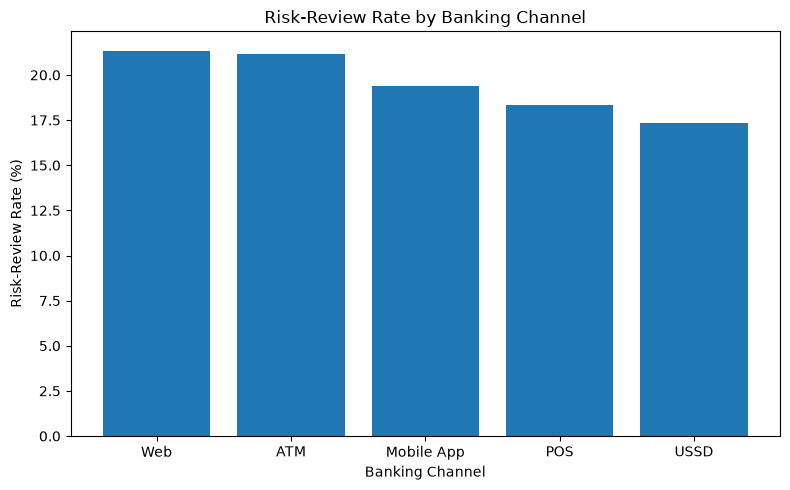

In [85]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_channel_summary["Channel"],
    risk_channel_summary["Risk_Review_Rate"]
)

plt.title("Risk-Review Rate by Banking Channel")
plt.xlabel("Banking Channel")
plt.ylabel("Risk-Review Rate (%)")

plt.tight_layout()
plt.show()

### Risk-Review Pattern Interpretation

#### What does the visual show?

The chart compares the proportion of transactions marked for risk review across FinTrust banking channels. Web and ATM have the highest risk-review rates at roughly 21%, followed by Mobile App at around 19%. POS is slightly lower, while USSD has the lowest risk-review rate at roughly 17%.

#### Why is it important?

Comparing risk-review rates by channel helps FinTrust identify whether transactions selected for review are more concentrated in particular banking channels. Using percentages allows the channels to be compared fairly even though their transaction volumes are different.

#### Business Insight

Web and ATM transactions have the highest proportion of transactions marked for risk review, while USSD has the lowest. However, the differences across channels are relatively moderate rather than extreme. This suggests that risk-review flags occur across all banking channels, although Web and ATM transactions may warrant closer descriptive investigation.

The Risk_Review_Flag is a synthetic educational indicator and should not be interpreted as confirmed fraud or as evidence that a particular banking channel causes risky transactions.